# Capacity-Constrained OT in One Dimension

This notebook generates `fig:capacity-constrained-ot-1d`.  It solves the entropic capacity-constrained transport problem
$$
    \min_{P\in U(a,b),\;0\leq P\leq U}
    \langle C,P\rangle + \epsilon\,\mathrm{KL}(P\mid a\otimes b),
    \qquad U_{ij}=\kappa a_i b_j,
$$
for two one-dimensional Gaussian-mixture histograms.  The three panels use the same source and target marginals and vary only the density-ratio cap \(\kappa\), starting with the unconstrained case \(\kappa=+\infty\).  Removing the cap recovers the usual entropic OT graph; small capacity forces the plan to spread because no entry can carry too much mass.

In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, PowerNorm, to_rgb

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    figure_dir,
    coupling_box,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "capacity-constrained-ot-1d"
OUT = figure_dir(FIGURE_NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_DIR = FIGROOT / "thumbnails"
THUMB_DIR.mkdir(exist_ok=True)


## KL-Dykstra projection

The entropic problem is a KL projection of the Gibbs reference matrix onto three convex sets: prescribed row sums, prescribed column sums, and an upper box.  Dykstra's correction factors are the only difference with ordinary alternating row/column Sinkhorn scaling.

In [2]:
def kl_dykstra_capacity(K, a, b, U, *, max_iter=30000, tol=1e-9, check_every=50):
    """KL-Dykstra projection of K onto row sums, column sums, and P <= U.

    Zero-capacity entries are kept at zero; 0/0 correction ratios are set to 1.
    """
    tiny = 1e-300
    allowed = U > 0
    P = np.where(allowed, np.minimum(K, U), 0.0)
    P = np.where(allowed, np.maximum(P, tiny), 0.0)
    corrections = [np.ones_like(P), np.ones_like(P), np.ones_like(P)]
    last_err = np.inf

    def safe_ratio(num, den):
        return np.divide(num, den, out=np.ones_like(num), where=den > tiny)

    for it in range(max_iter):
        Z = P * corrections[0]
        P_new = Z * (a / np.maximum(Z.sum(axis=1), tiny))[:, None]
        corrections[0] = safe_ratio(Z, P_new)
        P = np.where(allowed, P_new, 0.0)

        Z = P * corrections[1]
        P_new = Z * (b / np.maximum(Z.sum(axis=0), tiny))[None, :]
        corrections[1] = safe_ratio(Z, P_new)
        P = np.where(allowed, P_new, 0.0)

        Z = P * corrections[2]
        P_new = np.minimum(Z, U)
        corrections[2] = safe_ratio(Z, P_new)
        P = np.where(allowed, np.maximum(P_new, tiny), 0.0)

        if it % check_every == 0 or it == max_iter - 1:
            row_err = np.max(np.abs(P.sum(axis=1) - a))
            col_err = np.max(np.abs(P.sum(axis=0) - b))
            cap_err = max(float(np.max(P - U)), 0.0)
            last_err = max(row_err, col_err, cap_err)
            if last_err < tol:
                return P, it + 1, last_err
    return P, max_iter, last_err

def draw_matrix_with_marginals(P, a, b, path, *, gamma=0.55, normalize=True):
    n, m = P.shape
    fig, ax = plt.subplots(figsize=(2.35, 2.35))
    scale = max(P.max(), 1e-15) if normalize else 1.0
    image = (P / scale) ** gamma
    ax.imshow(
        image,
        cmap="Greys",
        origin="lower",
        extent=(-0.5, m - 0.5, -0.5, n - 0.5),
        interpolation="nearest",
        vmin=0,
        vmax=1,
        aspect="auto",
    )
    coupling_box(ax, n, m, linewidth=0.62)
    ax.set_xlim(-0.5 - 0.18 * m, m - 0.5)
    ax.set_ylim(-0.5, n - 0.5 + 0.18 * n)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    yy = np.arange(n)
    xx = np.arange(m)
    left_base = -0.5 - 0.020 * m
    left_scale = 0.13 * m / max(a.max(), 1e-15)
    ax.fill_betweenx(yy, left_base, left_base - left_scale * a, color=RED, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(left_base - left_scale * a, yy, color=RED, lw=0.95, zorder=4)

    top_base = n - 0.5 + 0.020 * n
    top_scale = 0.13 * n / max(b.max(), 1e-15)
    ax.fill_between(xx, top_base, top_base + top_scale * b, color=BLUE, alpha=0.18, linewidth=0, zorder=3)
    ax.plot(xx, top_base + top_scale * b, color=BLUE, lw=0.95, zorder=4)

    save_pdf(fig, path, pad_inches=0.025)
    plt.close(fig)


## Marginals and bounded plans

The grid is fine enough to show a smooth coupling image but small enough to keep the notebook quick.  Each displayed matrix is normalized by its own maximum so that the geometry of the support remains visible for all capacities.

In [3]:
def gaussian(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2.0 * np.pi))


def normalize(w):
    w = np.maximum(np.asarray(w, dtype=float), 1e-15)
    return w / w.sum()

n = 90
x = np.linspace(-3.0, 3.0, n)
alpha_density = (
    0.38 * gaussian(x, -1.25, 0.25)
    + 0.34 * gaussian(x, 0.05, 0.34)
    + 0.28 * gaussian(x, 1.20, 0.22)
)
beta_density = (
    0.28 * gaussian(x, -1.65, 0.22)
    + 0.44 * gaussian(x, 0.55, 0.28)
    + 0.28 * gaussian(x, 1.65, 0.30)
)
a = normalize(alpha_density)
b = normalize(beta_density)
C = (x[:, None] - x[None, :]) ** 2
C = C / C.max()
epsilon = 0.00075
K = np.outer(a, b) * np.exp(-C / epsilon)

kappas = [np.inf, 10.0, 2.6]
plans = []
logs = []
for kappa in kappas:
    U = kappa * np.outer(a, b)
    P, n_iter, err = kl_dykstra_capacity(K, a, b, U, max_iter=40000, tol=4e-9, check_every=50)
    plans.append(P)
    logs.append((kappa, n_iter, float(err), float(np.max(P / U)) if np.isfinite(kappa) else np.nan))

for name, P in zip(["large", "medium", "small"], plans):
    panel_path = OUT / f"{name}.pdf"
    draw_matrix_with_marginals(P, a, b, panel_path)
    shutil.copy2(panel_path, ARXIV_OUT / f"{FIGURE_NAME}--{name}.pdf")

print("kappa, iterations, residual, max(P/U)")
for kappa, n_iter, err, sat in logs:
    kappa_label = "+inf" if not np.isfinite(kappa) else f"{kappa:g}"
    sat_label = "n/a" if not np.isfinite(kappa) else f"{sat:.3f}"
    print((kappa_label, n_iter, f"{err:.2e}", sat_label))

assert all(np.max(np.abs(P.sum(axis=1) - a)) < 1e-7 for P in plans)
assert all(np.max(np.abs(P.sum(axis=0) - b)) < 1e-7 for P in plans)
assert all(np.max(P - k * np.outer(a, b)) < 1e-7 for P, k in zip(plans, kappas))


kappa, iterations, residual, max(P/U)
('+inf', 1701, '2.96e-09', 'n/a')
('10', 1801, '2.77e-09', '1.000')
('2.6', 10601, '3.88e-09', '1.000')


## Thumbnail

The manuscript arranges the PDF panels directly, without embedded titles.  The thumbnail below is only for the notebook gallery.

Exported panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/capacity-constrained-ot-1d
Thumbnail: /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/capacity-constrained-ot-1d.png


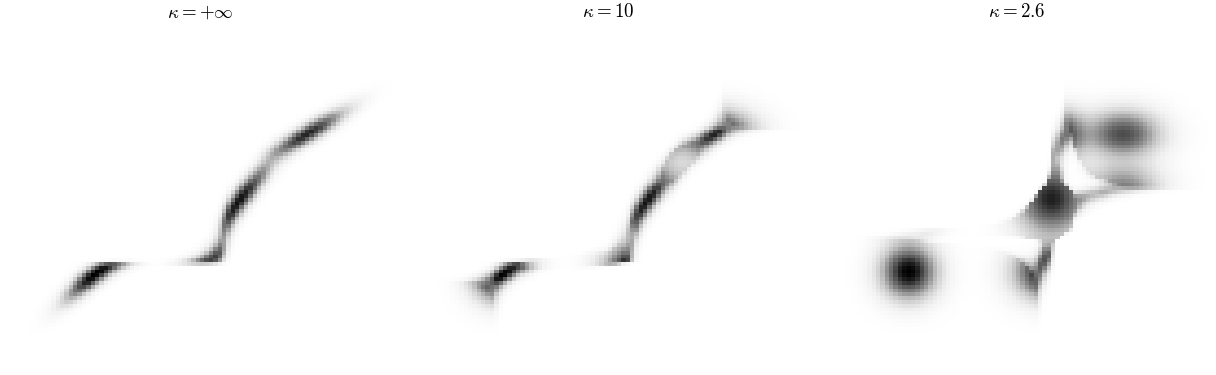

In [4]:
def make_thumbnail(plans, kappas, path):
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.25), constrained_layout=True)
    for ax, P, kappa in zip(axes, plans, kappas):
        ax.imshow((P / P.max()) ** 0.55, cmap="Greys", origin="lower", interpolation="nearest", aspect="auto")
        title = r"$\kappa=+\infty$" if not np.isfinite(kappa) else rf"$\kappa={kappa:g}$"
        ax.set_title(title, fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.savefig(path, dpi=170, bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)

thumb_path = THUMB_DIR / f"{FIGURE_NAME}.png"
make_thumbnail(plans, kappas, thumb_path)
print(f"Exported panels to {OUT}")
print(f"Thumbnail: {thumb_path}")
try:
    from IPython.display import Image, display
    display(Image(filename=str(thumb_path)))
except Exception:
    pass
